In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/intermediate/cleaned_orders.csv")

# Convert the date columns back to datetime (CSV save/load turns the datetime format into text)

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print("shape:", df.shape)


shape: (119140, 35)


In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,housewares,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,housewares,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,housewares,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,perfumery,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,21.0,auto,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18,2018-08-22 19:07:58


In [4]:
print(df["order_status"].value_counts())
print("\nPercentage:")
print((df["order_status"].value_counts(normalize=True) * 100).round(2))
                                    

order_status
delivered      115720
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

Percentage:
order_status
delivered      97.13
shipped         1.05
canceled        0.63
unavailable     0.55
invoiced        0.32
processing      0.32
created         0.00
approved        0.00
Name: proportion, dtype: float64


# EDA Important Insights
97.13% of orders were successfully delivered, indicating strong platform fulfillment and operational reliability.

Since cancelled, unavailable, and other incomplete orders do not represent actual customer purchases, they should be excluded from customer segmentation analysis.

For RFM (Recency, Frequency, Monetary) analysis, only delivered orders should be considered to ensure accurate calculation of customer behavior and value.


In [5]:
df_delivered = df[df["order_status"] == "delivered"].copy()
print("Delivered orders shape:", df_delivered.shape)

Delivered orders shape: (115720, 35)


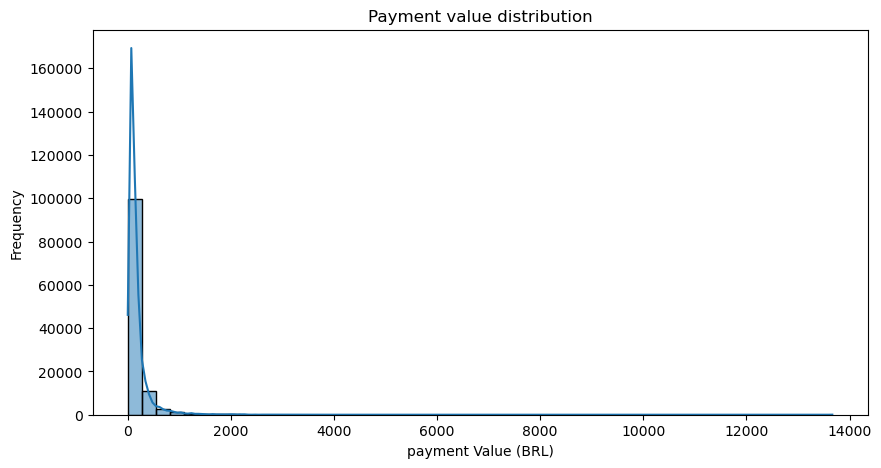

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df_delivered["payment_value"],bins=50, kde=True)
plt.title("Payment value distribution")
plt.xlabel("payment Value (BRL)")
plt.ylabel("Frequency")
plt.savefig("../reports/figures/payment_value_distribution.png")
plt.show()

# Business Insight
Payment values exhibit a highly right-skewed distribution, where the majority of transactions fall within the 0–500 BRL range, while a small number of transactions reach values of up to ~14,000 BRL. These high-value outliers represent premium customer behavior and can be valuable for customer segmentation by identifying a High-Value Customer cluster. However, because outliers can significantly influence distance-based algorithms and scaling methods such as StandardScaler, appropriate preprocessing (e.g., RobustScaler or log transformation) should be considered before model development.

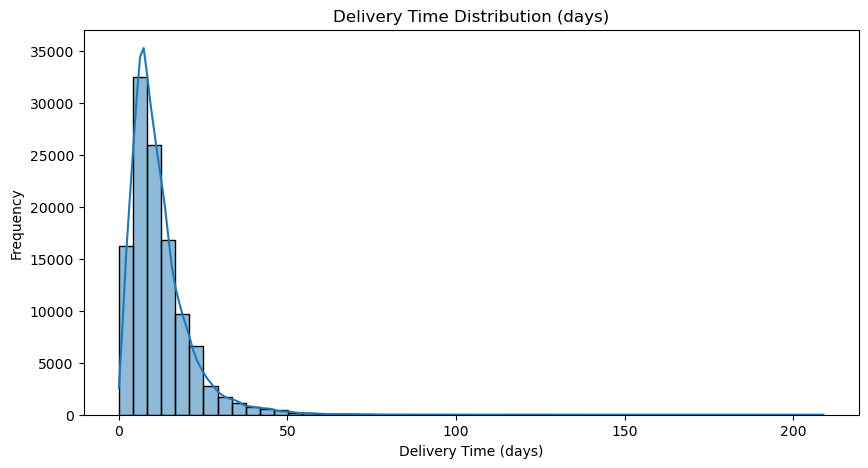

In [7]:
df_delivered["delivery_time_days"] = (
    df_delivered["order_delivered_customer_date"] - df_delivered["order_purchase_timestamp"]
).dt.days

plt.figure(figsize=(10,5))
sns.histplot(df_delivered["delivery_time_days"], bins=50, kde=True)
plt.title("Delivery Time Distribution (days)")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Frequency")
plt.savefig("../reports/figures/delivery_time_distribution.png")
plt.show()

# Business Insight

The average delivery time ranges between 5 and 15 days, reflecting the Olist platform's typical fulfillment speed. There are also some extreme delays (150+ days) that stand out as outliers; it would be interesting to correlate these with customer satisfaction (review scores), as late deliveries are likely to negatively impact ratings.

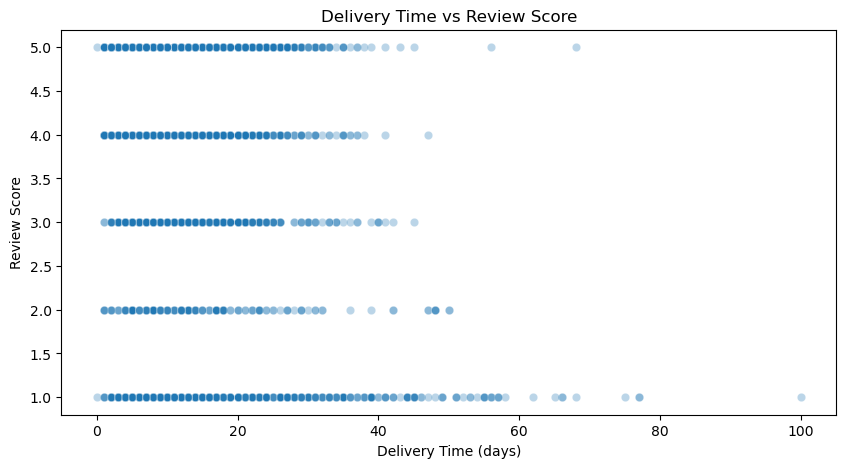

In [8]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x="delivery_time_days",
    y="review_score",
    data=df_delivered.sample(5000,random_state=42),
    alpha=0.3
)
plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Review Score")
plt.savefig("../reports/figures/delivery_vs_review.png")
plt.show()

# Important Business Insight

A negative relationship is evident between delivery time and review scores—as delivery time increases, the frequency of low review scores (1–2) rises, particularly for deliveries taking over 40 days. This makes delivery speed a critical factor for customer satisfaction. Including 'delivery experience' as a feature in segmentation could prove valuable.

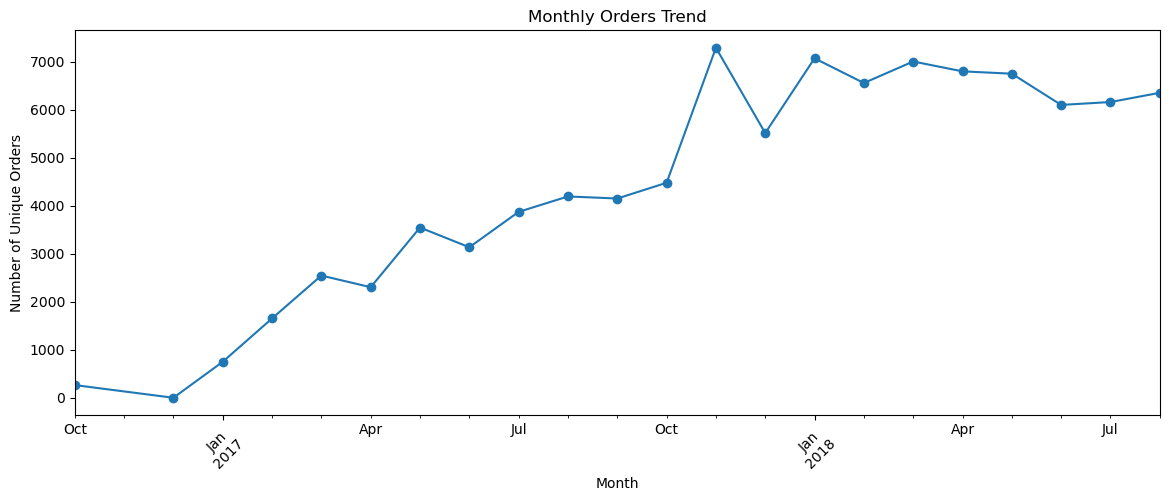

In [9]:
df_delivered["order_month"] = df_delivered["order_purchase_timestamp"].dt.to_period("M")

monthly_orders = df_delivered.groupby("order_month")["order_id"].nunique()

plt.figure(figsize=(14, 5))
monthly_orders.plot(kind="line", marker="o")
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Unique Orders")
plt.xticks(rotation=45)
plt.savefig("../reports/figures/monthly_orders_trend.png")
plt.show()

# Important Business Insight

Order volume showed strong growth from late 2016 through 2018, with a sharp spike in October–November 2017 that aligns with seasonal sales events (such as Black Friday). In the second half of 2018, orders stabilized in the 6,000–7,000 per month range, reflecting the platform's maturity.

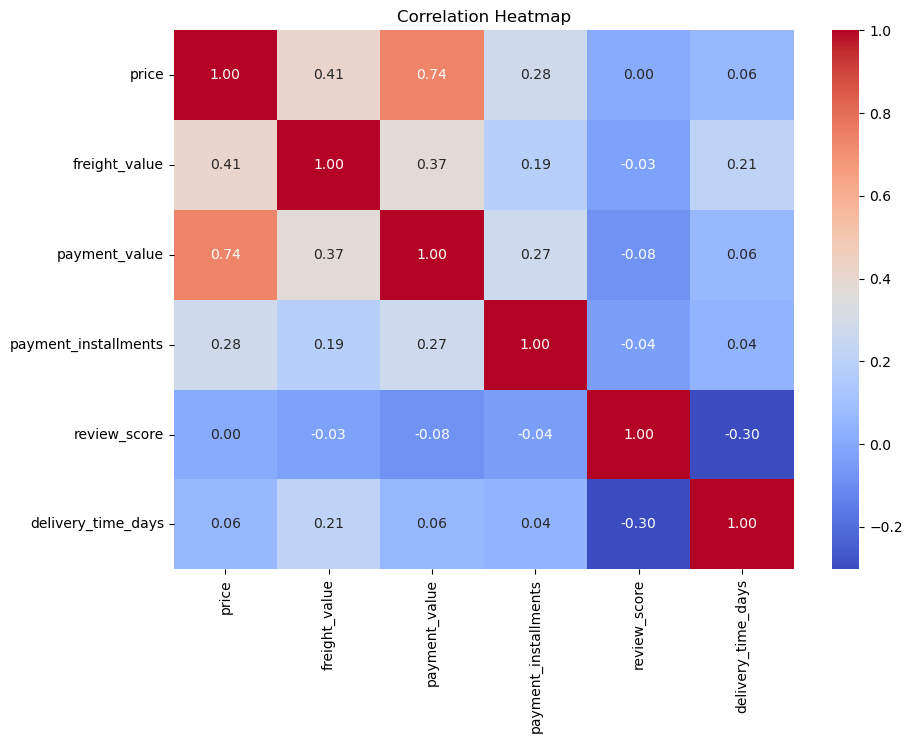

In [10]:
numeric_cols = ["price", "freight_value", "payment_value", "payment_installments", 
                 "review_score", "delivery_time_days"]

plt.figure(figsize=(10, 7))
sns.heatmap(df_delivered[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()

# Important Business Insight

Correlation analysis confirms that review scores are primarily driven by delivery time (correlation of -0.30), rather than price or payment amount (near-zero correlation). This suggests that to improve customer satisfaction, the company should focus on delivery logistics rather than pricing strategy. It also indicates that the 'delivery experience' could be a key factor in customer segmentation.

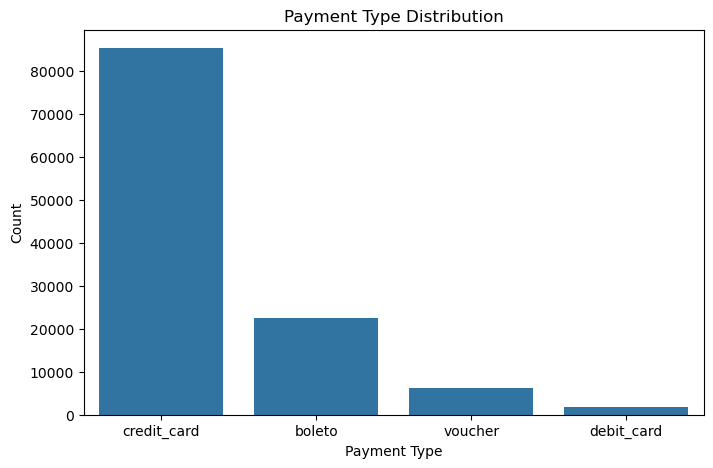

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_delivered, x="payment_type", order=df_delivered["payment_type"].value_counts().index)
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.savefig("../reports/figures/payment_type_distribution.png")
plt.show()

# Important Business Insight:

Credit cards are the dominant payment method on the Olist platform (accounting for ~75% of transactions), reflecting customer payment preferences and supporting installment-based purchases (as previously observed in the correlation with `payment_installments`).

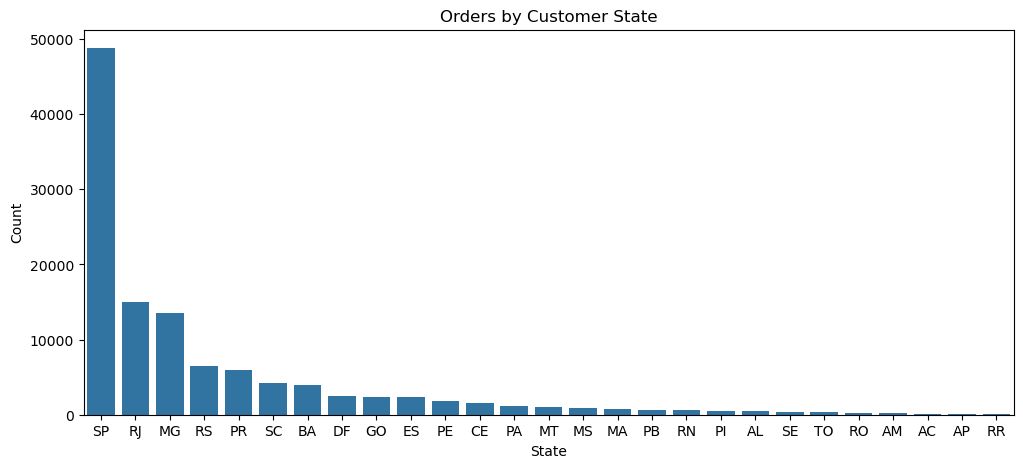

In [12]:
plt.figure(figsize=(12,5))
sns.countplot(
    data=df_delivered,
    x="customer_state",
    order=df_delivered["customer_state"].value_counts().index
)
plt.title("Orders by Customer State")
plt.xlabel("State")
plt.ylabel("Count")
plt.savefig("../reports/figures/orders_by_state.png")
plt.show()

# Important Business Insight

São Paulo is the dominant hub for the customer base (~42% of orders), likely due to it being Brazil's largest economic and population center. This geographic concentration is significant for the business—logistics and warehousing strategies can be centered on São Paulo, and any future geographic segmentation would require treating São Paulo differently from the other states.

In [16]:
customer_order_counts = df_delivered.groupby("customer_unique_id")["order_id"].nunique()

print("Total unique customers:", customer_order_counts.shape[0])
print("\nOrder frequency distribution:")
print(customer_order_counts.value_counts().head(10))

repeat_customers = (customer_order_counts > 1).sum()
repeat_percent = (repeat_customers / customer_order_counts.shape[0]) * 100
print(f"\nRepeat customers: {repeat_customers} ({repeat_percent:.2f}%)")

Total unique customers: 93357

Order frequency distribution:
order_id
1     90556
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

Repeat customers: 2801 (3.00%)
